In [1]:
import pandas as pd

In [11]:
df=pd.read_csv("train.csv",usecols=["Age","Fare","Survived"])

In [12]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
x=df.drop(columns=["Survived"])
y=df["Survived"]

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [23]:
x_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [25]:
x_train["Age_imputer"]=x_train["Age"]
x_test["Age_imputer"]=x_test["Age"]

In [27]:
x_train.head()

,Age,Fare,Age_imputer
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [29]:
x_train["Age_imputer"]=x_train["Age_imputer"].fillna(x_train["Age_imputer"].dropna().sample(x_train["Age_imputer"].isnull().sum(),replace=True).values)

TypeError: "value" parameter must be a scalar, dict or Series, but you passed a "ndarray"

In [35]:
# x_train["Age_imputer"] = x_train["Age"].copy()

x_train.loc[x_train["Age_imputer"].isnull(),"Age_imputer"] = x_train["Age_imputer"].dropna().sample(x_train["Age_imputer"].isnull().sum(),replace=True).values

In [36]:
x_train.sample(6)

,Age,Fare,Age_imputer
794,25.0,7.8958,25.0
82,NaN,7.7875,44.0
319,40.0,134.5000,40.0
605,36.0,15.5500,36.0
202,34.0,6.4958,34.0
734,23.0,13.0000,23.0


In [38]:
x_train.isnull().sum()
#here age_imputer fill values...

Age            148
Fare             0
Age_imputer      0
dtype: int64

In [43]:

import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='Density'>

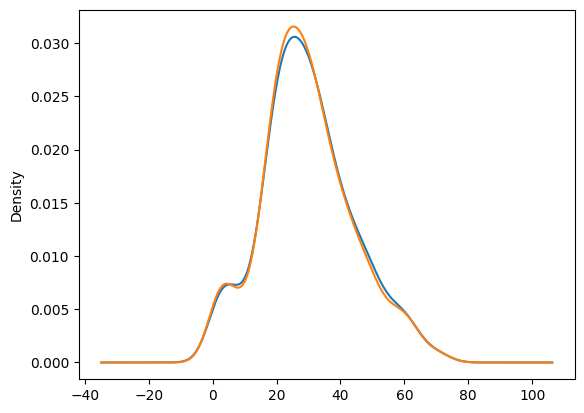

In [42]:
x_train["Age"].plot(kind="kde")
x_train["Age_imputer"].plot(kind="kde")

<Axes: xlabel='Age', ylabel='Density'>

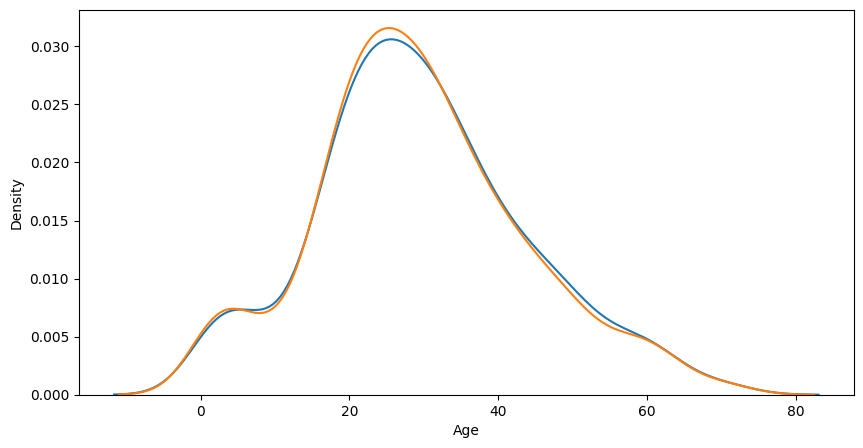

In [45]:
fig,ax=plt.subplots(1,1,figsize=(10,5))

sns.kdeplot(data=x_train,x="Age",ax=ax)
sns.kdeplot(data=x_train,x="Age_imputer",ax=ax)

In [47]:
x_train["Age"].var()

np.float64(204.34951339046142)

In [49]:
x_train["Age_imputer"].var()

np.float64(202.0349168973909)

In [52]:
x_train[["Fare","Age","Age_imputer"]].cov()

,Fare,Age,Age_imputer
Fare,2368.246832,71.512440,60.405593
Age,71.512440,204.349513,204.349513
Age_imputer,60.405593,204.349513,202.034917


<Axes: >

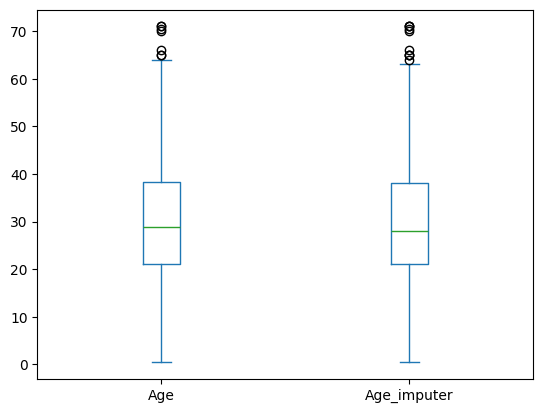

In [54]:
x_train[["Age","Age_imputer"]].plot(kind="box")

In [2]:
#categorical data.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
data=pd.read_csv("house-train.csv",usecols=["GarageQual","FireplaceQu","SalePrice"])

In [40]:
data.columns

Index(['FireplaceQu', 'GarageQual', 'SalePrice'], dtype='str')

In [41]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [42]:
data.shape

(1460, 3)

In [43]:
data.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

In [44]:
x=data.drop(columns=["SalePrice"])
y=data["SalePrice"]

In [20]:
from sklearn.model_selection import train_test_split

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
x_train.head()

,FireplaceQu,GarageQual
254,NaN,TA
1066,TA,TA
638,NaN,NaN
799,TA,TA
380,Gd,TA


In [47]:
x_train["GarageQual_imputer"]=x_train["GarageQual"]
x_test["GarageQual_imputer"]=x_test["GarageQual"]

In [48]:
x_train["FireplaceQu_imputer"]=x_train["FireplaceQu"]
x_test["FireplaceQu_imputer"]=x_test["FireplaceQu"]

In [49]:
x_train.head()

,FireplaceQu,GarageQual,GarageQual_imputer,FireplaceQu_imputer
254,NaN,TA,TA,NaN
1066,TA,TA,TA,TA
638,NaN,NaN,NaN,NaN
799,TA,TA,TA,TA
380,Gd,TA,TA,Gd


In [32]:
#random value selection.

In [50]:
x_train.loc[x_train["GarageQual_imputer"].isnull(),"GarageQual_imputer"]=x_train["GarageQual_imputer"].dropna().sample(x_train["GarageQual_imputer"].isnull().sum(),replace=True).values

In [69]:
x_train.sample(5)

,FireplaceQu,GarageQual,GarageQual_imputer,FireplaceQu_imputer
1289,Gd,TA,TA,Gd
626,TA,TA,TA,TA
441,NaN,NaN,TA,NaN
446,Gd,TA,TA,Gd
33,Gd,TA,TA,Gd


In [71]:
x_train.loc[x_train["FireplaceQu_imputer"].isnull(),"FireplaceQu_imputer"]=x_train["FireplaceQu_imputer"].dropna().sample(x_train["FireplaceQu_imputer"].isnull().sum(),replace=True).values

In [74]:
x_train.sample(5)

,FireplaceQu,GarageQual,GarageQual_imputer,FireplaceQu_imputer
225,NaN,TA,TA,Gd
771,NaN,TA,TA,TA
6,Gd,TA,TA,Gd
207,Po,TA,TA,Po
100,TA,TA,TA,TA


In [76]:
#checking frequency



In [78]:
x_train["GarageQual"].value_counts(normalize=True)

GarageQual
TA    0.951087
Fa    0.032609
Gd    0.011775
Ex    0.002717
Po    0.001812
Name: proportion, dtype: float64

In [82]:
x_train["GarageQual_imputer"].value_counts(normalize=True)

GarageQual_imputer
TA    0.952911
Fa    0.030822
Gd    0.011986
Ex    0.002568
Po    0.001712
Name: proportion, dtype: float64

In [83]:
x_train["FireplaceQu"].value_counts(normalize=True)

FireplaceQu
Gd    0.491143
TA    0.405797
Fa    0.043478
Ex    0.033816
Po    0.025765
Name: proportion, dtype: float64

In [84]:
x_train["FireplaceQu_imputer"].value_counts(normalize=True)

FireplaceQu_imputer
Gd    0.505137
TA    0.392123
Fa    0.041952
Ex    0.032534
Po    0.028253
Name: proportion, dtype: float64

In [ ]:
#if the frequency remail almost the same then random value imputation worked well.

In [80]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   FireplaceQu          621 non-null    str  
 1   GarageQual           1104 non-null   str  
 2   GarageQual_imputer   1168 non-null   str  
 3   FireplaceQu_imputer  1168 non-null   str  
dtypes: str(4)
memory usage: 45.6 KB
